In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -q "/content/drive/MyDrive/data/dataset.zip" -d .
!ls            # expect a 'dataset' folder
!ls dataset    # expect 'set 23' and 'val 23'

dataset  drive	sample_data
'set 23'  'val 23'


In [3]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
IMG_SIZE = (256,256)
TRAIN_DIR = "/content/dataset/set 23"
VAL_DIR   = "/content/dataset/val 23"

# Create training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=32,
)

# Create validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=32,
)

num_classes = len(train_ds.class_names)
print(num_classes)

Found 2800 files belonging to 4 classes.
Using 2240 files for training.
Found 2800 files belonging to 4 classes.
Using 560 files for validation.
4


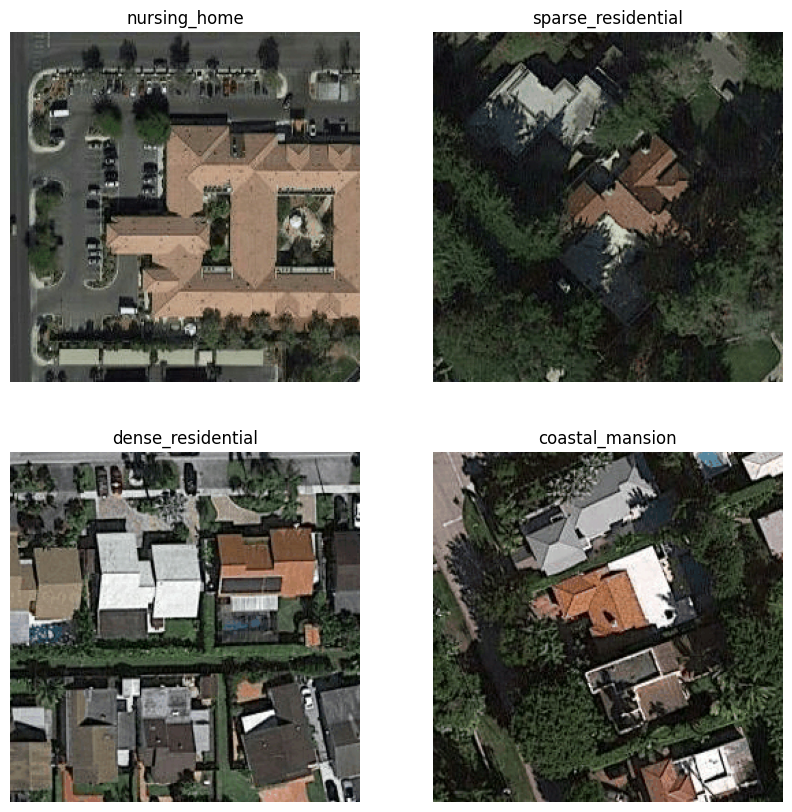

In [4]:
import numpy as np

# Get class names from train_ds
class_names = train_ds.class_names

# Dictionary to store one image per class
images_per_class = {}

# Iterate through the training dataset to collect one image for each class
for images, labels in train_ds:
    for i in range(images.shape[0]):
        label_index = labels[i].numpy()
        class_name = class_names[label_index]
        if class_name not in images_per_class:
            images_per_class[class_name] = images[i].numpy()

    if len(images_per_class) == len(class_names): # Stop once all classes have an image
        break

# Display one image for each class
plt.figure(figsize=(10, 10))
for i, (class_name, image) in enumerate(images_per_class.items()):
    ax = plt.subplot(2, 2, i + 1) # Arrange in 2x2 grid
    plt.imshow(image.astype("uint8"))
    plt.title(class_name)
    plt.axis("off")
plt.show()

(32, 256, 256, 3)
(32,)


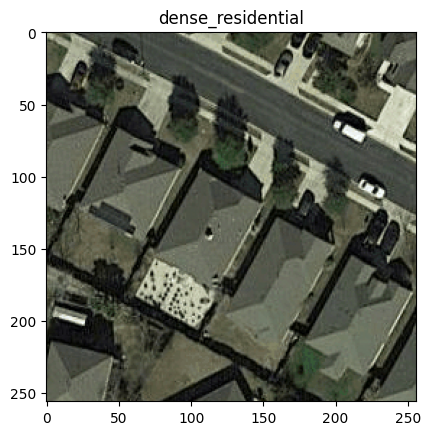

In [5]:
image, label = next(iter(train_ds))
print(image.shape)
print(label.shape)

class_names = train_ds.class_names
get_label_name = lambda x: class_names[x]

plt.imshow(image[0].numpy().astype("uint8"))
plt.title(get_label_name(label[0]))
plt.show()

In [6]:
def augmentation() -> keras.Sequential:
  return keras.Sequential([
      keras.layers.RandomFlip("horizontal_and_vertical"),
      keras.layers.RandomRotation(0.1),
      keras.layers.RandomZoom(0.2),
      keras.layers.Resizing(*IMG_SIZE),
      keras.layers.Rescaling(1./255)
  ])

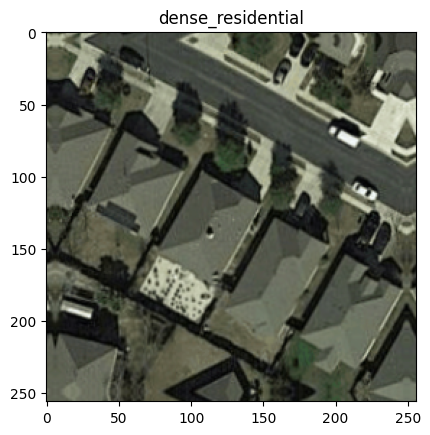

In [7]:
result = augmentation()(image)
plt.imshow(result[0].numpy())
plt.title(get_label_name(label[0]))
plt.show()

In [8]:
print("Min and max pixel values:", result.numpy().min(), result.numpy().max())

Min and max pixel values: 0.0 1.0


In [9]:
def build_model(num_classes: int, augmentation: keras.Sequential) -> keras.Model:
    inputs = keras.Input(shape=IMG_SIZE + (3,))

    x = augmentation(inputs)

    # Convolutional Block 1
    x = keras.layers.Conv2D(256,(3,3), activation='relu', strides=(1,1))(x)
    x = keras.layers.MaxPooling2D((2, 2), padding='valid')(x)
    x = keras.layers.BatchNormalization()(x)

    # Convolutional Block 2
    x = keras.layers.Conv2D(128,(3,3), activation='relu', strides=(1,1))(x)
    x = keras.layers.MaxPooling2D((2, 2), padding='valid')(x)
    x = keras.layers.BatchNormalization()(x)

    # Convolutional Block 3
    x = keras.layers.Conv2D(128,(3,3), activation='relu', strides=(1,1))(x)

    # Convolutional Block 4
    x = keras.layers.Conv2D(128,(3,3), activation='relu', strides=(1,1))(x)

    # Convolutional Block 5
    x = keras.layers.Conv2D(64,(3,3), activation='relu', strides=(1,1))(x)
    x = keras.layers.MaxPooling2D((2, 2), padding='valid')(x)

    # Fully Connected Layers
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(512, activation='relu')(x)
    x = keras.layers.Dense(256, activation='relu')(x)
    x = keras.layers.Dense(64, activation='relu')(x)
    x = keras.layers.Dense(16, activation='relu')(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

In [10]:
model = build_model(num_classes, augmentation())
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 256)  │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 127, 127, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 128)  │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 62, 62, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,512,212 (101.14 MB)

 Trainable params: 26,511,444 (101.13 MB)

 Non-trainable params: 768 (3.00 KB)

In [11]:
EPOCH = 30
BATCH_SIZE = 32
LEARNING_RATE = 0.00025

callback = [
    keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.25,
    patience=4,
    min_lr= 1e-6
)

]

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)

In [12]:
run_model = model.fit(
    train_ds,
    epochs=EPOCH,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    callbacks=callback
)

Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 47s 477ms/step - loss: 1.1646 - sparse_categorical_accuracy: 0.4080 - val_loss: 1.5533 - val_sparse_categorical_accuracy: 0.2536 - learning_rate: 2.5000e-04
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 30s 429ms/step - loss: 0.6841 - sparse_categorical_accuracy: 0.7040 - val_loss: 2.0298 - val_sparse_categorical_accuracy: 0.2536 - learning_rate: 2.5000e-04
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 31s 448ms/step - loss: 0.5168 - sparse_categorical_accuracy: 0.8152 - val_loss: 2.2886 - val_sparse_categorical_accuracy: 0.2536 - learning_rate: 2.5000e-04
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 31s 445ms/step - loss: 0.3684 - sparse_categorical_accuracy: 0.8616 - val_loss: 2.6033 - val_sparse_categorical_accuracy: 0.3893 - learning_rate: 2.5000e-04
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 31s 449ms/step - loss: 0.2992 - sparse_categorical_accuracy: 0.8991 - val_loss: 2.9011 - val_sparse_categorical_accuracy: 0.2589 - learning_rate: 2.5000e-04
Epoch 6/30
70/70 ━━━━━━━━

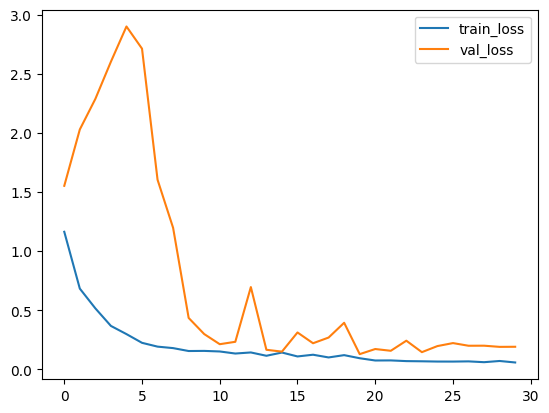

In [13]:
plt.plot(run_model.history['loss'], label='train_loss')
plt.plot(run_model.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

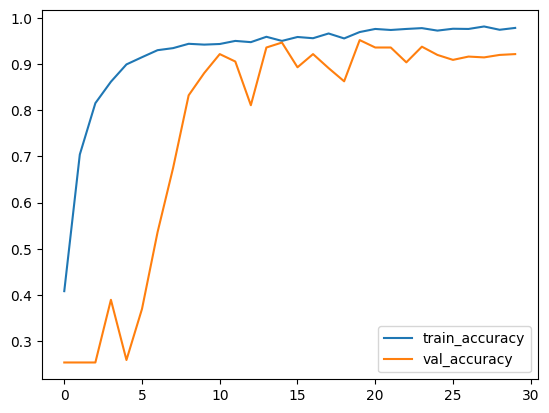

In [14]:
plt.plot(run_model.history['sparse_categorical_accuracy'], label='train_accuracy')
plt.plot(run_model.history['val_sparse_categorical_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

In [15]:
from sklearn.utils import shuffle
real_test = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=8,
    shuffle = False
)

test_loss, test_acc = model.evaluate(real_test)
print(f"Test accuracy: {test_acc * 100:.2f}%")

Found 400 files belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.1389 - sparse_categorical_accuracy: 0.9400
Test accuracy: 94.00%


Save model to google drive.

In [16]:
model.save('drive/MyDrive/test_customcnn.keras')